# GeomechPy — Full 1D Mechanical Earth Model Workflow

This notebook builds a complete **1D Mechanical Earth Model (MEM)** the way it is done in practice, from raw well logs to a drilling mud weight window:

```
 well logs (DTCO, DTSH, RHOB)
   └─► 1. dynamic elastic properties        (rock physics)
         └─► 2. static calibration           (core-calibrated correlations)
               └─► 3. rock strength           (UCS, tensile, friction angle)
 depth (TVD)
   └─► 4. pore pressure                      (gradient / EMW)
   └─► 5. overburden stress                  (density-log integration)
         └─► 6. horizontal stresses          (Eaton Shmin + SHmax)
               └─► 7. fracture gradient
               └─► 8. mud weight window       (kick / breakout / loss / breakdown)
                     └─► 9. visualization
```

We use **synthetic logs** so the notebook is fully reproducible, but every step works identically with real LAS/DLIS data loaded into a pandas DataFrame.

In [1]:
import numpy as np
import pandas as pd

from geomechpy import (
    DynamicElasticPropertiesCalculation,
    FractureGradientCalculation,
    HorizontalStressesCalculation,
    OverburdenStressCalculation,
    PorePressureCalculation,
    RockStrengthPropertiesConverter,
    StaticElasticPropertiesConverter,
    UnitConverter,
    WellboreStabilityCalculation,
    add_results_to_dataframe,
    plot_elastic_properties,
    plot_mem_profile,
    plot_mud_weight_window,
    plot_stress_polygon,
)

## Step 0 — Prepare the log data

We simulate a 2,000 ft section (8,000–10,000 ft TVD) sampled every 10 ft. The synthetic curves follow **compaction trends** — slowness decreases and density increases with depth — with small correlated noise, which is what a shaly-sand section typically looks like.

With real data you would replace this cell with e.g. `lasio.read("well.las").df()`.

In [2]:
rng = np.random.default_rng(42)

tvd = np.arange(8000.0, 10000.0 + 10.0, 10.0)                       # ft
n = len(tvd)
trend = (tvd - tvd[0]) / (tvd[-1] - tvd[0])                          # 0 -> 1 down the section
noise = rng.normal(0.0, 1.0, n).cumsum() / np.sqrt(n)                # smooth correlated noise

logs = pd.DataFrame(
    {
        "dtco": 88.0 - 14.0 * trend + 1.2 * noise,                   # us/ft, compacting
        "dtsh": 158.0 - 28.0 * trend + 2.0 * noise,                  # us/ft
        "rhob": 2480.0 + 130.0 * trend - 6.0 * noise,                # kg/m3
    },
    index=pd.Index(tvd, name="tvd"),
)
logs.describe().loc[["min", "mean", "max"]].round(1)

,dtco,dtsh,rhob
min,73.5,129.2,2479.9
mean,80.7,143.5,2546.4
max,88.0,158.0,2612.4


## Step 1 — Dynamic elastic properties

The sonic and density logs give the **dynamic** moduli directly ($G=\rho V_s^2$, $M=\rho V_p^2$). The `_array` methods take plain lists, so the DataFrame columns feed straight in, and `add_results_to_dataframe` brings the results back as columns with a `dyn_` prefix.

In [3]:
dynamic = DynamicElasticPropertiesCalculation.calculate_from_slowness_array(
    logs["dtco"].tolist(), logs["dtsh"].tolist(), logs["rhob"].tolist(),
    modulus_unit="Mpsi",           # handy for the correlations that follow
)
logs = add_results_to_dataframe(logs, dynamic, prefix="dyn_")
logs[["dtco", "dyn_youngs_modulus", "dyn_poissons_ratio", "dyn_vp_vs_ratio"]].head().round(3)

,dtco,dyn_youngs_modulus,dyn_poissons_ratio,dyn_vp_vs_ratio
tvd,,,,
8000.0,88.026,3.412,0.275,1.795
8010.0,87.868,3.426,0.275,1.795
8020.0,87.861,3.427,0.275,1.795
8030.0,87.871,3.428,0.275,1.795
8040.0,87.636,3.448,0.275,1.795


## Step 2 — Static calibration

Stress and stability calculations need **static** moduli. Here we use the Najibi power-law calibration for Young's modulus and keep the dynamic Poisson's ratio (multiplier 1.0) — with core data you would fit `convert_dyn2sta_yme_custom_power_law` instead.

In [4]:
logs["sta_youngs_modulus"] = StaticElasticPropertiesConverter.dyn2sta_yme_najib_array(
    logs["dyn_youngs_modulus"].tolist()
)
logs["sta_poissons_ratio"] = StaticElasticPropertiesConverter.dyn2sta_poissons_ratio_array(
    logs["dyn_poissons_ratio"].tolist(), multiplier=1.0
)
print(f"E dynamic {logs['dyn_youngs_modulus'].mean():.2f} Mpsi  ->  E static {logs['sta_youngs_modulus'].mean():.2f} Mpsi (mean)")

E dynamic 4.28 Mpsi  ->  E static 1.28 Mpsi (mean)


## Step 3 — Rock strength

- **UCS** from the static Young's modulus (Plumb generic)
- **Tensile strength** as 15% of UCS
- **Friction angle** from DTCO (Lal — a shale correlation, acceptable for this shaly section)

In [5]:
logs["ucs"] = RockStrengthPropertiesConverter.convert_yme_sta_to_ucs_plumb_array(
    logs["sta_youngs_modulus"].tolist()
)
logs["tstr"] = RockStrengthPropertiesConverter.convert_ucs_to_tstr_array(logs["ucs"].tolist())
logs["fang"] = RockStrengthPropertiesConverter.convert_friction_angle_lal_array(logs["dtco"].tolist())
logs[["ucs", "tstr", "fang"]].describe().loc[["min", "mean", "max"]].round(1)

,ucs,tstr,fang
min,1169.4,175.4,33.5
mean,1853.3,278.0,35.6
max,2790.8,418.6,37.7


## Step 4 & 5 — Pore pressure and overburden

Pore pressure uses a slightly overpressured **9.0 ppg** equivalent gradient (typical hand-off from a pore pressure analyst). Overburden is obtained by **integrating the density log** — more realistic than a constant lithostatic gradient because it honors the actual compaction profile.

In [6]:
logs["pore_pressure"] = PorePressureCalculation.calculate_pore_pressure_onshore_array(
    tvd=logs.index.tolist(), formation_pore_pressure_gradient=9.0, gradient_unit="ppg"
)
logs["overburden"] = OverburdenStressCalculation.calculate_overburden_stress_from_density_array(
    tvd=logs.index.tolist(), density=logs["rhob"].tolist()
)
print(f"At TD: Pp = {logs['pore_pressure'].iloc[-1]:.0f} psi, Sv = {logs['overburden'].iloc[-1]:.0f} psi "
      f"({logs['overburden'].iloc[-1]/logs.index[-1]:.3f} psi/ft average)")

At TD: Pp = 4675 psi, Sv = 10809 psi (1.081 psi/ft average)


## Step 6 — Horizontal stresses

**Shmin** from Eaton's uniaxial-strain equation using the static Poisson's ratio, and **SHmax** from a modest 1.05 anisotropy multiplier (calibrate against breakout/DIF observations when available). The result is a normal-faulting regime: $P_p < S_{hmin} \le S_{Hmax} < S_v$.

In [7]:
logs["shmin"] = HorizontalStressesCalculation.calculate_shmin_eaton_array(
    overburden_stress=logs["overburden"].tolist(),
    pore_pressure=logs["pore_pressure"].tolist(),
    poisson_ratio=logs["sta_poissons_ratio"].tolist(),
)
logs["shmax"] = HorizontalStressesCalculation.calculate_shmax_multiplier_array(
    shmin=logs["shmin"].tolist(), shmax_multiplier=1.05
)
ordered = (logs["pore_pressure"] < logs["shmin"]).all() and (logs["shmax"] < logs["overburden"]).all()
print(f"Normal faulting ordering (Pp < Shmin <= SHmax < Sv) at every depth: {ordered}")

Normal faulting ordering (Pp < Shmin <= SHmax < Sv) at every depth: True


## Step 7 — Fracture gradient

The Hubbert & Willis bounds bracket the fracture pressure; Eaton's estimate (equal to the Eaton Shmin) usually sits between them and is the common planning value.

In [8]:
logs["frac_hw_min"] = FractureGradientCalculation.calculate_fracture_pressure_hubbert_willis_min_array(
    logs["overburden"].tolist(), logs["pore_pressure"].tolist()
)
logs["frac_hw_max"] = FractureGradientCalculation.calculate_fracture_pressure_hubbert_willis_max_array(
    logs["overburden"].tolist(), logs["pore_pressure"].tolist()
)
logs[["frac_hw_min", "shmin", "frac_hw_max"]].iloc[-1].round(0)

frac_hw_min    6720.0
shmin          6837.0
frac_hw_max    7742.0
Name: 10000.0, dtype: float64

## Step 8 — Mud weight window

The four operational limits at every depth: **kick** (pore pressure), **breakout** (Mohr-Coulomb shear failure), **losses** (Shmin) and **breakdown** (fracture initiation).

In [9]:
windows = WellboreStabilityCalculation.calculate_mud_weight_window_vertical_well_array(
    shmax=logs["shmax"].tolist(), shmin=logs["shmin"].tolist(),
    pprs=logs["pore_pressure"].tolist(), overburden_stress=logs["overburden"].tolist(),
    ucs=logs["ucs"].tolist(), fang=logs["fang"].tolist(),
    pr_sta=logs["sta_poissons_ratio"].tolist(), tstr=logs["tstr"].tolist(),
)
logs = add_results_to_dataframe(logs, windows)

# The tightest point of the section, in equivalent mud weight
lower_ppg = UnitConverter.convert_pressure_to_mud_weight_array(
    [max(w.kick_pressure, w.breakout_pressure) for w in windows], logs.index.tolist()
)
upper_ppg = UnitConverter.convert_pressure_to_mud_weight_array(
    [min(w.loss_pressure, w.breakdown_pressure) for w in windows], logs.index.tolist()
)
logs["emw_lower"], logs["emw_upper"] = lower_ppg, upper_ppg
tightest = logs.index[np.argmin(logs["emw_upper"] - logs["emw_lower"])]
print(f"Safe EMW at TD:        {logs['emw_lower'].iloc[-1]:.2f} - {logs['emw_upper'].iloc[-1]:.2f} ppg")
print(f"Tightest window at {tightest:.0f} ft: {logs.loc[tightest, 'emw_lower']:.2f} - {logs.loc[tightest, 'emw_upper']:.2f} ppg")

Safe EMW at TD:        10.63 - 13.16 ppg
Tightest window at 8000 ft: 11.67 - 13.44 ppg


### How does well trajectory change the picture?

The numerical deviated-well solver evaluates the Kirsch effective stresses around the borehole wall for any trajectory. Sweeping deviation at TD shows the window narrowing as the well turns horizontal — and, in rock this weak, closing entirely: beyond ~60° the mud needed to stop breakouts would already fracture the formation. This is exactly the analysis used to decide whether a horizontal section is drillable or the casing shoe needs to come deeper.

In [10]:
td = logs.index[-1]
at_td = logs.loc[td]
print("Deviation   safe EMW window at TD")
for deviation in [0, 30, 60, 90]:
    try:
        window = WellboreStabilityCalculation.calculate_mud_weight_window_deviated_well(
            shmax=at_td["shmax"], shmin=at_td["shmin"], pprs=at_td["pore_pressure"],
            overburden_stress=at_td["overburden"], ucs=at_td["ucs"], fang=at_td["fang"],
            pr_sta=at_td["sta_poissons_ratio"], tstr=at_td["tstr"],
            borehole_deviation=deviation, borehole_azimuth=90.0,
        )
    except ValueError:
        # In this weak rock the borehole wall shears at ANY mud pressure once the
        # well turns horizontal - the solver tells you instead of returning nonsense
        print(f"  {deviation:3d} deg    no stable window (shear failure at any mud pressure)")
        continue
    lo = UnitConverter.convert_pressure_to_mud_weight(max(window.kick_pressure, window.breakout_pressure), td)
    hi = UnitConverter.convert_pressure_to_mud_weight(min(window.loss_pressure, window.breakdown_pressure), td)
    if lo >= hi:
        print(f"  {deviation:3d} deg    window closed - mud needed to stop breakouts ({lo:.2f} ppg) exceeds the loss limit ({hi:.2f} ppg)")
    else:
        print(f"  {deviation:3d} deg    {lo:5.2f} - {hi:5.2f} ppg")

Deviation   safe EMW window at TD
    0 deg    10.63 - 13.16 ppg
   30 deg    11.85 - 13.16 ppg


   60 deg    window closed - mud needed to stop breakouts (13.37 ppg) exceeds the loss limit (13.16 ppg)
   90 deg    no stable window (shear failure at any mud pressure)


## Step 9 — Visualization

### Elastic properties log

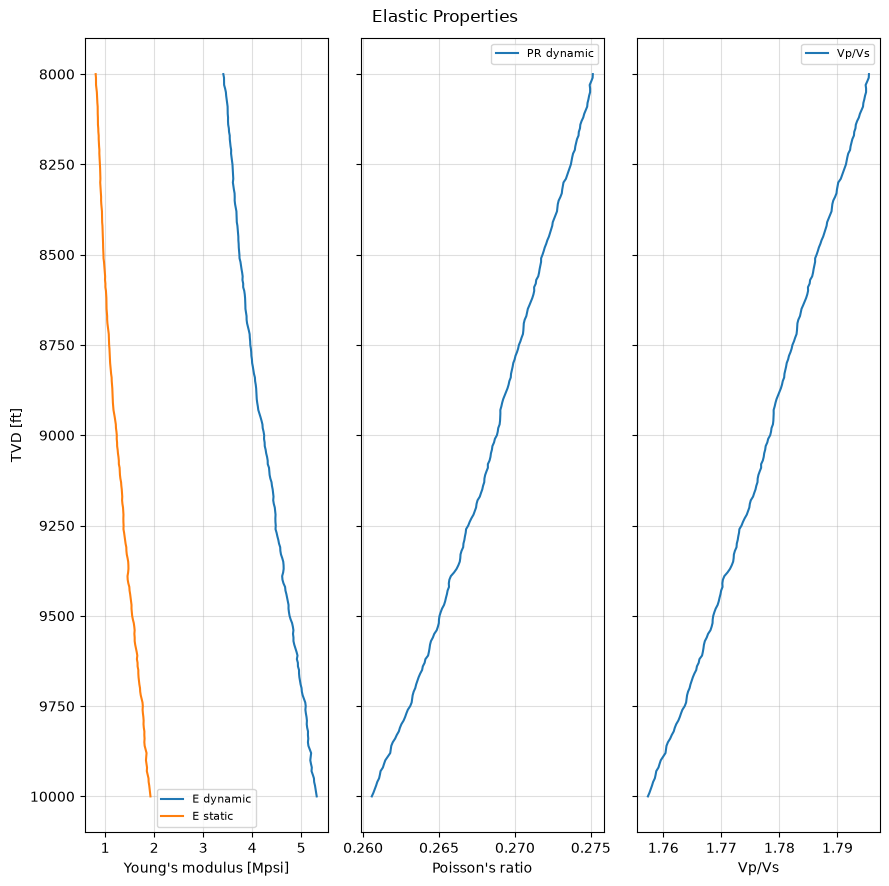

In [11]:
figure = plot_elastic_properties(
    logs.index.tolist(), dynamic,
    static_youngs_modulus=logs["sta_youngs_modulus"].tolist(),
    modulus_unit="Mpsi",
)

### The MEM composite profile

The industry-standard multi-track display: pressures and stresses, rock strength, and the input logs side by side on a shared depth axis.

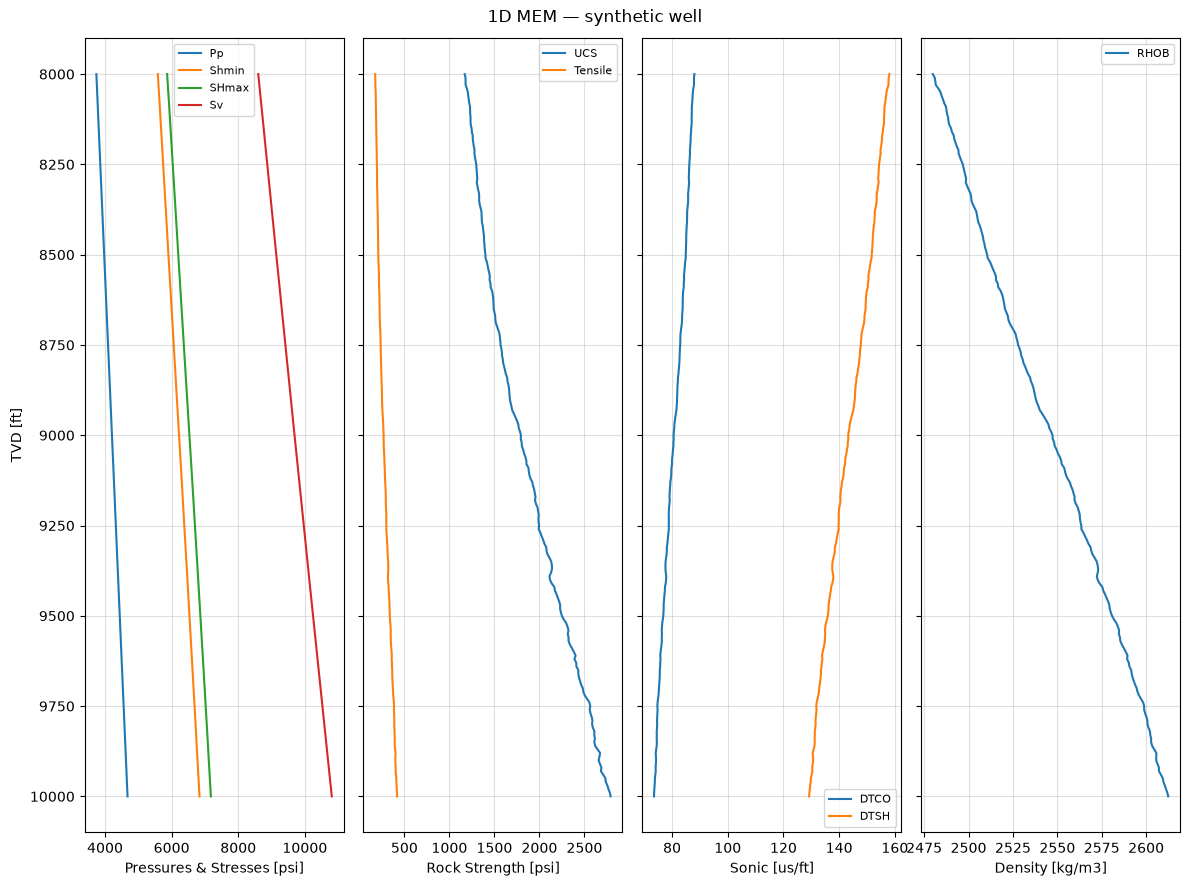

In [12]:
figure = plot_mem_profile(
    logs.index.tolist(),
    tracks={
        "Pressures & Stresses": {
            "Pp": logs["pore_pressure"], "Shmin": logs["shmin"],
            "SHmax": logs["shmax"], "Sv": logs["overburden"],
        },
        "Rock Strength": {"UCS": logs["ucs"], "Tensile": logs["tstr"]},
        "Sonic": {"DTCO": logs["dtco"], "DTSH": logs["dtsh"]},
        "Density": {"RHOB": logs["rhob"]},
    },
    track_units={"Pressures & Stresses": "psi", "Rock Strength": "psi", "Sonic": "us/ft", "Density": "kg/m3"},
    title="1D MEM — synthetic well",
)

### The mud weight window

Shown in **equivalent mud weight**, the way it goes onto the drilling program. The green band is the safe window; a candidate 10.5 ppg mud is overlaid.

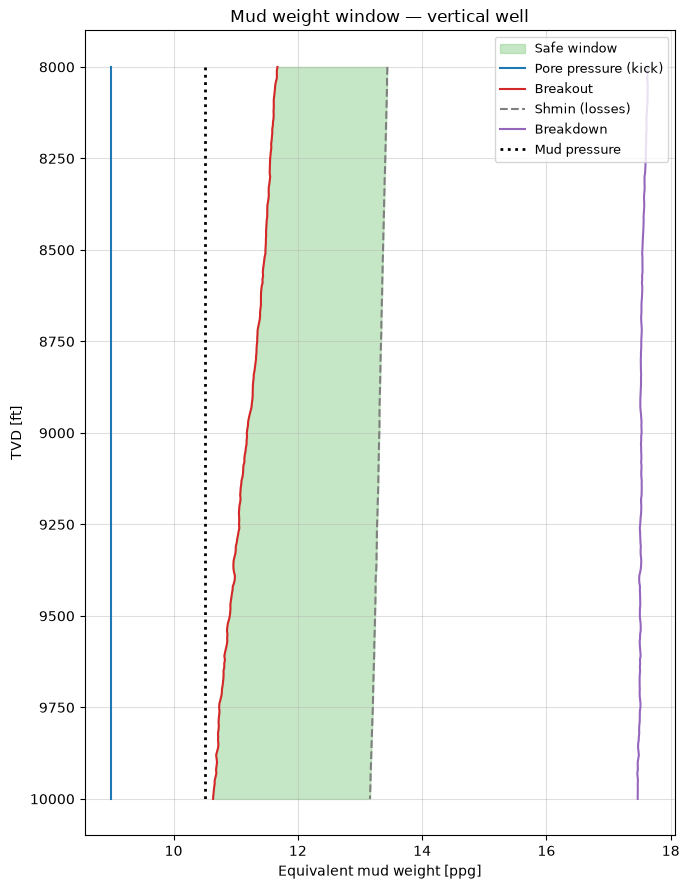

In [13]:
mud_plan_psi = UnitConverter.convert_mud_weight_to_pressure_array(
    [10.5] * len(logs), logs.index.tolist()
)
figure = plot_mud_weight_window(
    logs.index.tolist(), windows,
    as_mud_weight=True, mud_weight_unit="ppg",
    mud_pressure=mud_plan_psi,
    title="Mud weight window — vertical well",
)

### The stress state at TD on the stress polygon

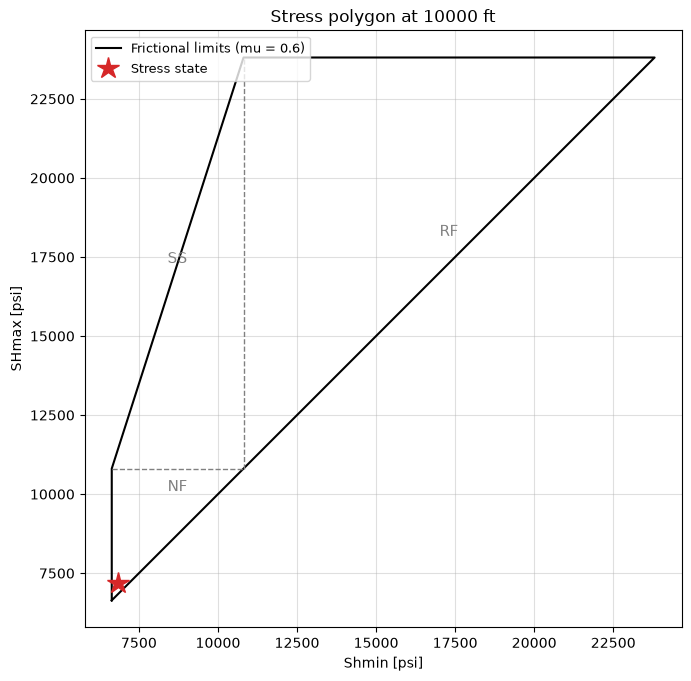

In [14]:
figure = plot_stress_polygon(
    shmin=at_td["shmin"], shmax=at_td["shmax"],
    overburden_stress=at_td["overburden"], pore_pressure=at_td["pore_pressure"],
    title=f"Stress polygon at {td:.0f} ft",
)

## Summary

Starting from three log curves and a pore pressure gradient we built, step by step:

1. dynamic elastic moduli (rock physics) → 2. static calibration → 3. UCS / tensile / friction angle → 4. pore pressure → 5. density-integrated overburden → 6. Eaton Shmin + SHmax → 7. fracture gradient → 8. mud weight window (vertical **and** deviated) → 9. the standard displays.

The whole model lives in one tidy DataFrame — ready to export (`logs.to_csv(...)`) or compare against offset wells:

In [15]:
logs[["pore_pressure", "shmin", "shmax", "overburden", "ucs", "emw_lower", "emw_upper"]].tail().round(1)

,pore_pressure,shmin,shmax,overburden,ucs,emw_lower,emw_upper
tvd,,,,,,,
9960.0,4656.6,6812.6,7153.3,10763.4,2737.2,10.7,13.2
9970.0,4661.3,6818.8,7159.7,10774.7,2754.8,10.7,13.2
9980.0,4666.0,6824.8,7166.0,10786.0,2767.5,10.6,13.2
9990.0,4670.6,6830.8,7172.4,10797.3,2782.4,10.6,13.2
10000.0,4675.3,6836.7,7178.5,10808.6,2790.8,10.6,13.2
